In [10]:

!pip install opencv-python opencv-python-headless datasets scikit-learn

zsh:1: /Users/igyeongseob/Develop/ai/RAG/vectorDB/vector/venv/bin/pip: bad interpreter: /Users/igyeongseob/Develop/ai/vector/venv/bin/python3: no such file or directory
^C


In [ ]:

import cv2
import numpy as np
from datasets import load_dataset
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [11]:

dataset = load_dataset("keremberke/shoe-classification", "default", revision="refs/convert/parquet")
dataset = dataset["train"]

In [12]:
dataset

Dataset({
    features: ['image_file_path', 'image', 'labels'],
    num_rows: 578
})

In [ ]:
def extract_sift_features(image):
    sift = cv2.SIFT_create()   # SIFT detector 생성
    keypoints, descriptors = sift.detectAndCompute(image, None) # keypoint 검출 + descriptor 추출
    return descriptors



In [24]:

image_descriptors = []

for imageset in dataset:
    image = np.array(imageset['image'])
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    descriptors = extract_sift_features(gray_image)

    if descriptors is not None:
        descriptors = descriptors.astype(np.float32)
        image_descriptors.append(descriptors)
    else:
        image_descriptors.append(np.zeros((1, 128), dtype=np.float32))

# KMeans 클러스터링을 위한 SIFT 벡터 Vertical Stack
all_descriptors = np.vstack([desc for desc in image_descriptors if desc is not None])

num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(all_descriptors)

def image_to_histogram(image_desc):
    labels = kmeans.predict(image_desc)
    hist, _ = np.histogram(labels, bins=np.arange(num_clusters+1), density=True)
    return hist

image_histograms = [image_to_histogram(desc) for desc in image_descriptors]

In [46]:
codebook = kmeans.cluster_centers_
codebook

array([[30.650604 , 19.55284  , 15.542612 , ..., 20.43546  , 14.500101 ,
        21.899208 ],
       [22.459248 , 30.236492 , 36.24623  , ..., 17.866468 , 21.271347 ,
        20.313541 ],
       [14.094552 , 15.21272  , 19.103449 , ...,  9.416012 , 10.514155 ,
        12.982228 ],
       ...,
       [21.035542 ,  7.9349194,  5.56843  , ...,  5.159595 ,  3.6663756,
        10.042412 ],
       [45.739143 , 33.135822 , 19.465183 , ...,  6.084768 ,  5.034896 ,
         6.9599867],
       [12.665569 ,  9.769844 , 10.264713 , ...,  3.5600748,  2.9286375,
        10.588372 ]], shape=(10, 128), dtype=float32)

In [25]:
image_histograms[50]

array([0.18103448, 0.12068966, 0.05172414, 0.0387931 , 0.06896552,
       0.05172414, 0.14224138, 0.15948276, 0.10344828, 0.08189655])

In [26]:

def extract_and_draw_keypoints_quantized(image, kmeans_model):
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray_image, None)

    if descriptors is None:
        return image

    descriptors = descriptors.astype(np.float32)
    labels = kmeans_model.predict(descriptors)

    output_image = image.copy()
    for keypoint, label in zip(keypoints, labels):
        color = plt.cm.get_cmap('hsv', num_clusters)(label)
        color = tuple([int(x * 255) for x in color[:3]])
        x, y = keypoint.pt
        cv2.circle(output_image, (int(x), int(y)), 3, color, -1)

    return output_image

def extract_and_draw_keypoints(image):
    if not isinstance(image, np.ndarray):
        image = np.array(image)

    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    sift = cv2.SIFT_create()
    keypoints, _ = sift.detectAndCompute(gray_image, None)
    keypoint_image = cv2.drawKeypoints(image, keypoints, None)
    return keypoint_image

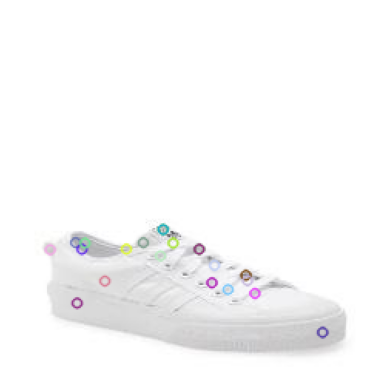

In [27]:
#생성된 SIFT VECTOR의 Keypoints 확인
query_img_with_keypoints = extract_and_draw_keypoints(dataset[0]['image'])
plt.imshow(query_img_with_keypoints)
plt.axis('off')
plt.show()

/var/folders/95/t8symb5521g2916cz4qtrsjc0000gn/T/ipykernel_5460/805761551.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap('hsv', num_clusters)(label)


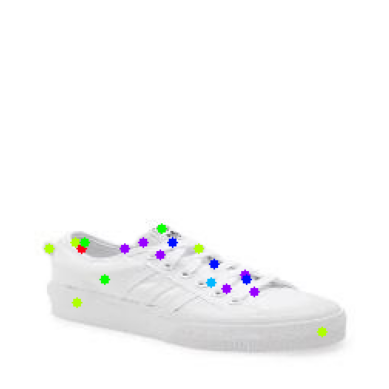

In [28]:
#생성된 SIFT VECTOR의 Quantized Keypoints 확인
colored_keypoints_image = extract_and_draw_keypoints_quantized(np.array(dataset[0]['image']), kmeans)
plt.imshow(colored_keypoints_image)
plt.axis('off')
plt.show()

In [29]:

#이미지 검색
def retrieve_images(query_idx, histograms, top_k=3):
    query_hist = histograms[query_idx]
    similarities = [cosine_similarity(query_hist.reshape(1, -1), hist.reshape(1, -1))[0][0] for hist in histograms]

    # 쿼링 이미지 제외 나머지 이미지들에 대해 일괄적으로 코사인 유사도 기준 소팅
    similarities = [(idx, sim) for idx, sim in enumerate(similarities) if idx != query_idx]
    similarities.sort(key=lambda x: x[1], reverse=True)

    # 가장 유사한 이미지와 안비슷한 이미지 추출
    similar_images = [idx for idx, _ in similarities[:top_k]]
    dissimilar_images = [idx for idx, _ in similarities[-top_k:]]

    return similar_images, dissimilar_images

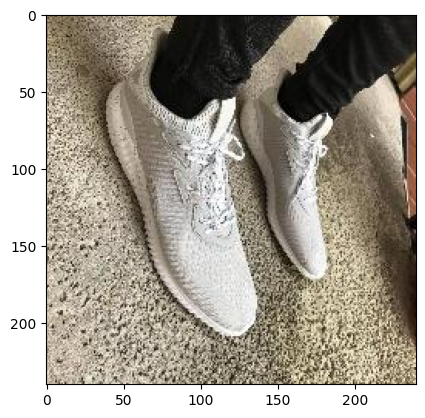

In [30]:
plt.imshow(dataset[65]['image'])

/var/folders/95/t8symb5521g2916cz4qtrsjc0000gn/T/ipykernel_5460/805761551.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap('hsv', num_clusters)(label)


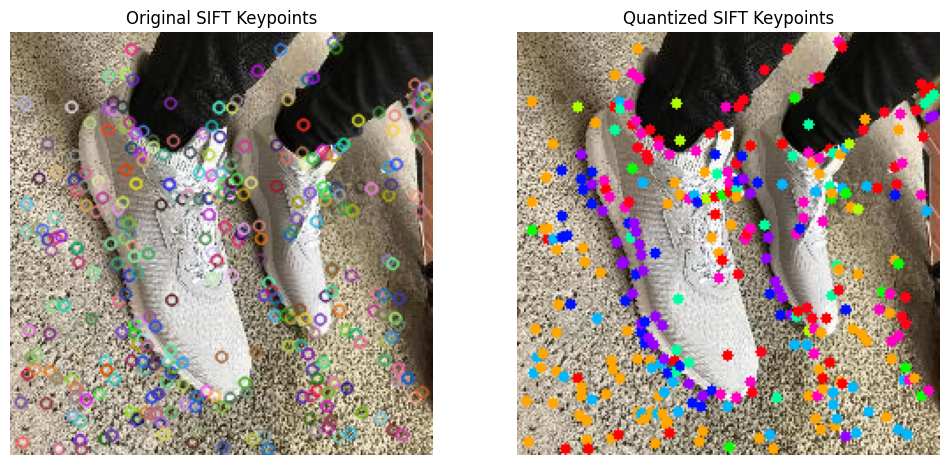

In [31]:

query_idx = 65
similar_images, dissimilar_images = retrieve_images(query_idx, image_histograms)
#생성된 SIFT VECTOR의 keypoints 확인
query_img_with_keypoints = extract_and_draw_keypoints(dataset[query_idx]['image'])
colored_keypoints_image = extract_and_draw_keypoints_quantized(np.array(dataset[query_idx]['image']), kmeans)
plt.figure(figsize=(12, 6))

# Original keypoints
plt.subplot(1, 2, 1)
plt.imshow(query_img_with_keypoints)
plt.title('Original SIFT Keypoints')
plt.axis('off')

# Quantized keypoints
plt.subplot(1, 2, 2)
plt.imshow(colored_keypoints_image)
plt.title('Quantized SIFT Keypoints')
plt.axis('off')

plt.show()

559
532
223


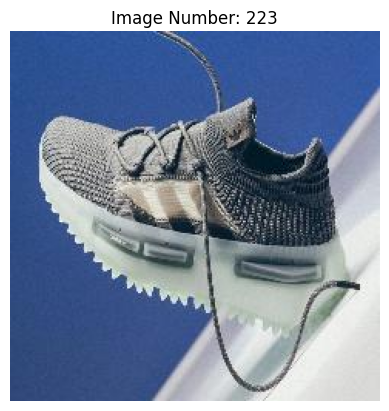

In [43]:

for i in similar_images:
    print(i)
    plt.imshow(dataset[i]['image'])
    plt.title(f'Image Number: {i}')
    plt.axis('off')


In [34]:
dissimilar_images

[501, 334, 0]

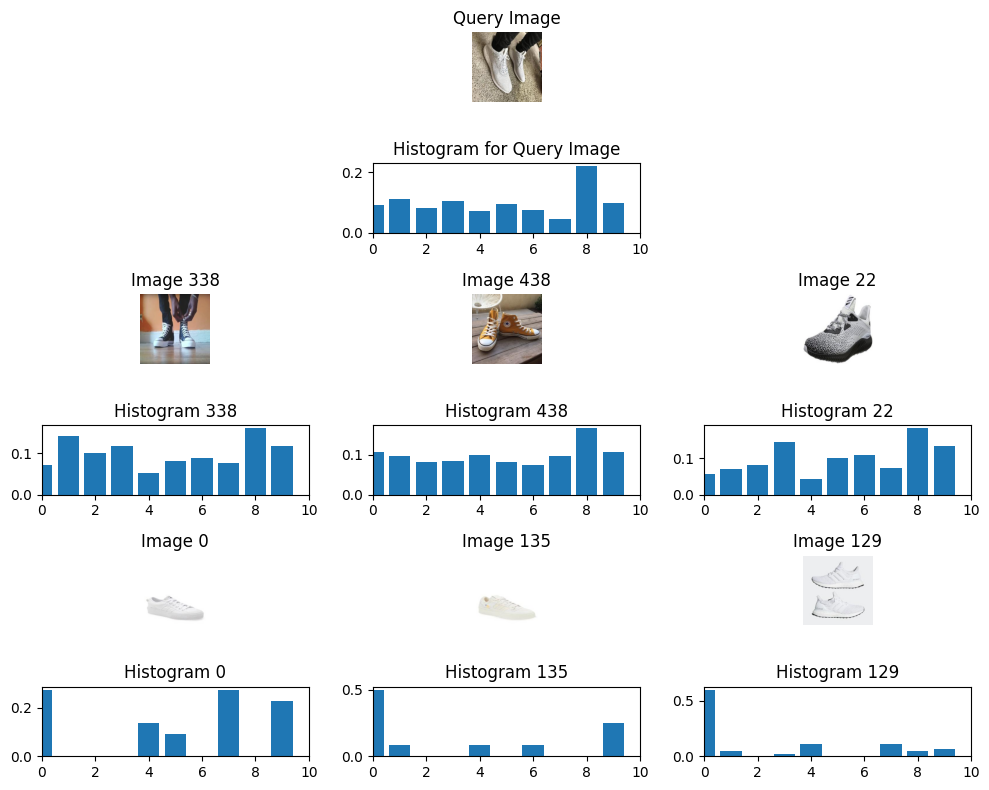

In [15]:

def display_row_of_images_and_histograms(image_indices, row, gs, num_bins):
    for i, idx in enumerate(image_indices):
        ax_img = plt.subplot(gs[row, i])
        ax_img.imshow(dataset[idx]['image'])
        ax_img.set_title(f'Image {idx}')
        ax_img.axis('off')

        ax_hist = plt.subplot(gs[row + 1, i])
        ax_hist.bar(range(num_bins), image_histograms[idx])
        ax_hist.set_title(f'Histogram {idx}')
        ax_hist.set_xlim([0, num_bins])

plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(6, 3)

plt.subplot(gs[0, :])
plt.imshow(dataset[query_idx]['image'])
plt.title('Query Image')
plt.axis('off')

plt.subplot(gs[1, 1])
plt.bar(range(num_clusters), image_histograms[query_idx])
plt.title('Histogram for Query Image')
plt.xlim([0, num_clusters])

display_row_of_images_and_histograms(similar_images, 2, gs, num_clusters)

display_row_of_images_and_histograms(dissimilar_images, 4, gs, num_clusters)

plt.tight_layout()
plt.show()

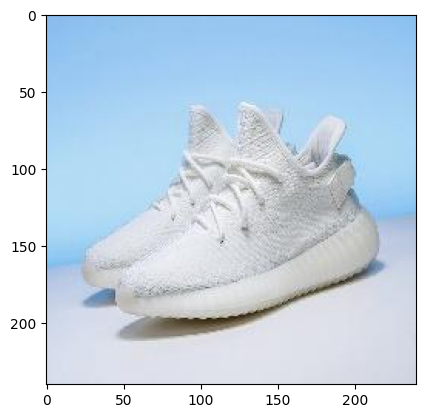

In [16]:
plt.imshow(dataset[94]['image'])

/var/folders/95/t8symb5521g2916cz4qtrsjc0000gn/T/ipykernel_18744/805761551.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap('hsv', num_clusters)(label)


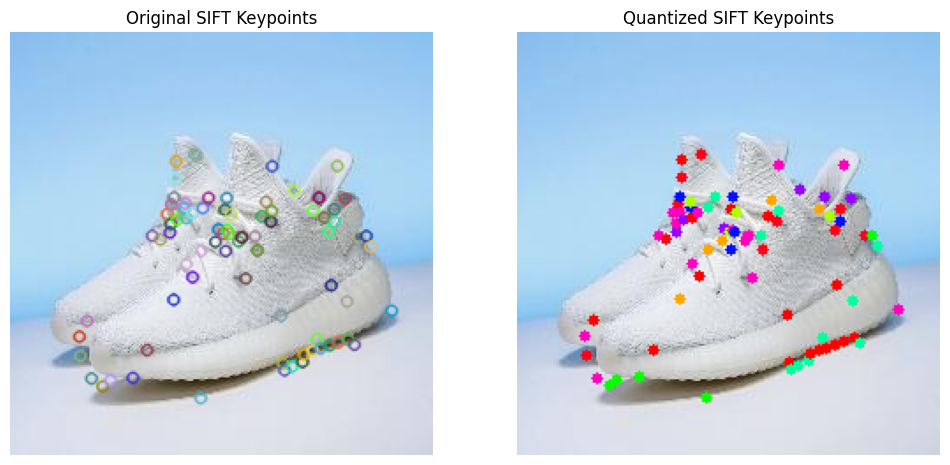

In [17]:
query_idx = 94
similar_images, dissimilar_images = retrieve_images(query_idx, image_histograms)
#생성된 SIFT VECTOR의 keypoints 확인
query_img_with_keypoints = extract_and_draw_keypoints(dataset[query_idx]['image'])
colored_keypoints_image = extract_and_draw_keypoints_quantized(np.array(dataset[query_idx]['image']), kmeans)
plt.figure(figsize=(12, 6))

# Original keypoints
plt.subplot(1, 2, 1)

plt.imshow(query_img_with_keypoints)
plt.title('Original SIFT Keypoints')
plt.axis('off')

# Quantized keypoints
plt.subplot(1, 2, 2)

plt.imshow(colored_keypoints_image)
plt.title('Quantized SIFT Keypoints')
plt.axis('off')

plt.show()

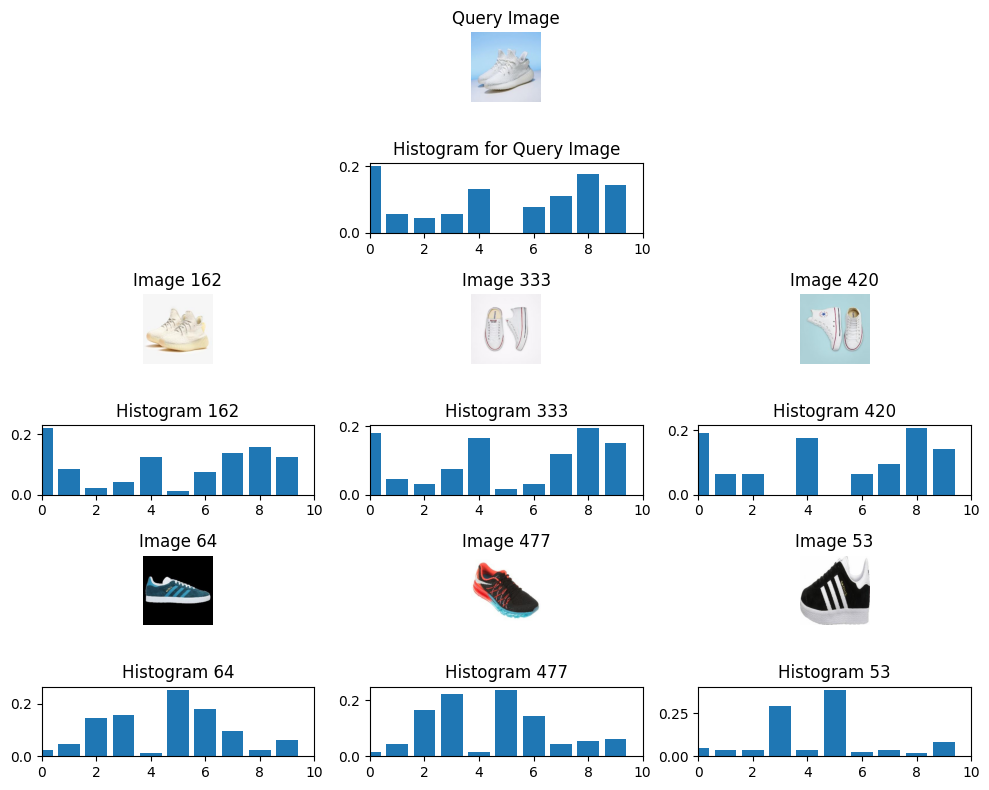

In [18]:

def display_row_of_images_and_histograms(image_indices, row, gs, num_bins):
    for i, idx in enumerate(image_indices):
        ax_img = plt.subplot(gs[row, i])
        ax_img.imshow(dataset[idx]['image'])
        ax_img.set_title(f'Image {idx}')
        ax_img.axis('off')

        ax_hist = plt.subplot(gs[row + 1, i])
        ax_hist.bar(range(num_bins), image_histograms[idx])
        ax_hist.set_title(f'Histogram {idx}')
        ax_hist.set_xlim([0, num_bins])

plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(6, 3)

plt.subplot(gs[0, :])
plt.imshow(dataset[query_idx]['image'])
plt.title('Query Image')
plt.axis('off')

plt.subplot(gs[1, 1])
plt.bar(range(num_clusters), image_histograms[query_idx])
plt.title('Histogram for Query Image')
plt.xlim([0, num_clusters])

display_row_of_images_and_histograms(similar_images, 2, gs, num_clusters)

display_row_of_images_and_histograms(dissimilar_images, 4, gs, num_clusters)

plt.tight_layout()
plt.show()

/var/folders/95/t8symb5521g2916cz4qtrsjc0000gn/T/ipykernel_18744/805761551.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap('hsv', num_clusters)(label)


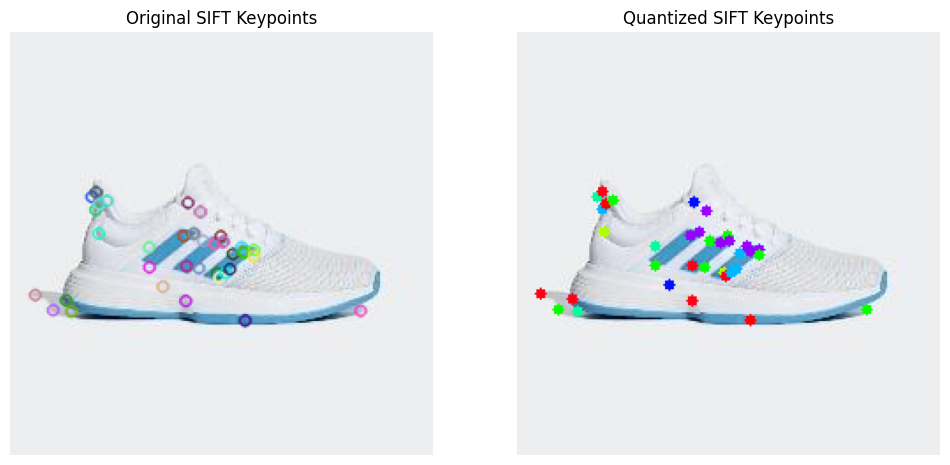

In [19]:
query_idx = 155
similar_images, dissimilar_images = retrieve_images(query_idx, image_histograms)
#생성된 SIFT VECTOR의 keypoints 확인
query_img_with_keypoints = extract_and_draw_keypoints(dataset[query_idx]['image'])
colored_keypoints_image = extract_and_draw_keypoints_quantized(np.array(dataset[query_idx]['image']), kmeans)
plt.figure(figsize=(12, 6))

# Original keypoints
plt.subplot(1, 2, 1)

plt.imshow(query_img_with_keypoints)
plt.title('Original SIFT Keypoints')
plt.axis('off')

# Quantized keypoints
plt.subplot(1, 2, 2)

plt.imshow(colored_keypoints_image)
plt.title('Quantized SIFT Keypoints')
plt.axis('off')

plt.show()

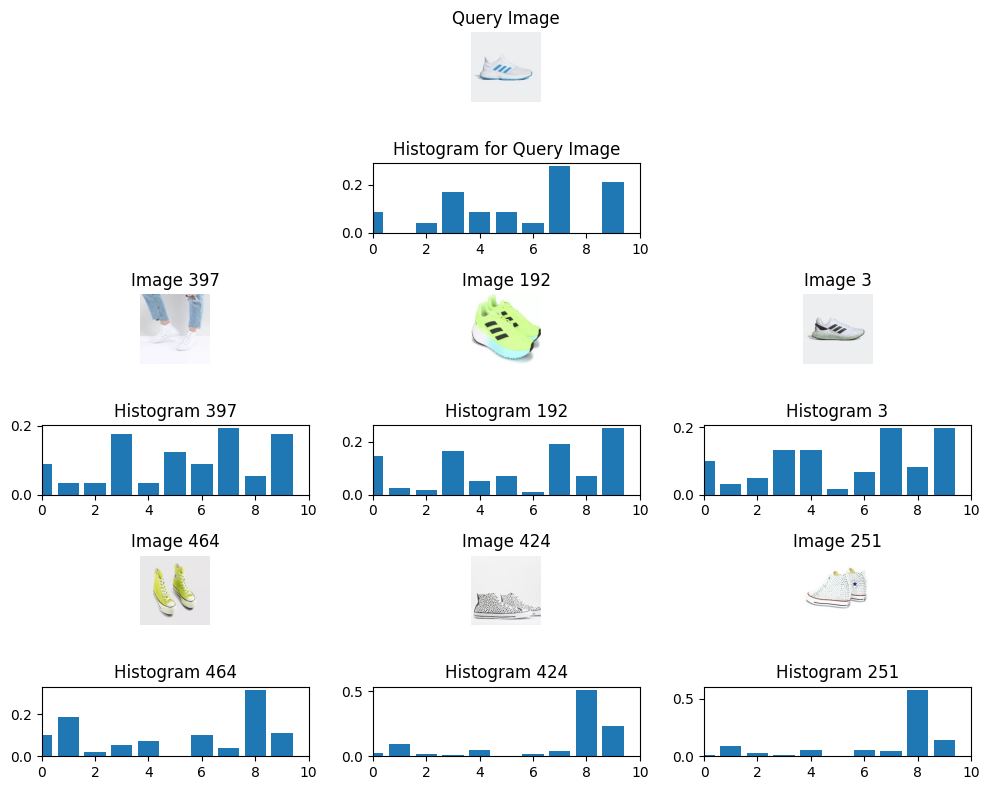

In [20]:

plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(6, 3)

plt.subplot(gs[0, :])
plt.imshow(dataset[query_idx]['image'])
plt.title('Query Image')
plt.axis('off')

plt.subplot(gs[1, 1])
plt.bar(range(num_clusters), image_histograms[query_idx])
plt.title('Histogram for Query Image')
plt.xlim([0, num_clusters])

display_row_of_images_and_histograms(similar_images, 2, gs, num_clusters)

display_row_of_images_and_histograms(dissimilar_images, 4, gs, num_clusters)

plt.tight_layout()
plt.show()